In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy as sp

In [2]:
df = pd.read_csv('../../../DataBox/lrAssumption.csv')

In [3]:
# IO
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

# TTS
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

# Apply lr
model = LinearRegression()
model.fit(X_train,y_train)

# Residual
y_pred = model.predict(X_test)
residual = y_test - y_pred

1. Linear Relationship

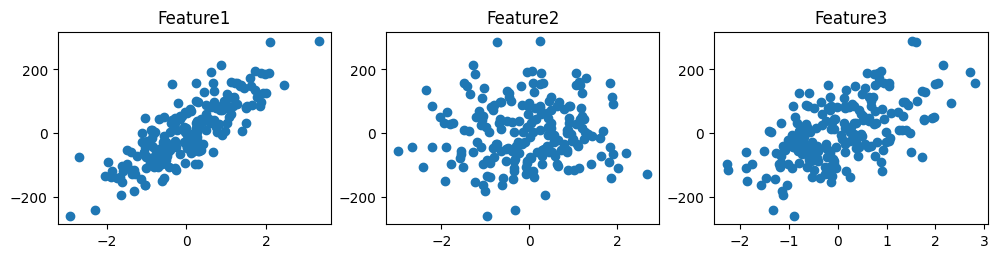

In [4]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")

plt.show()

# Observation 
# feature1 is clearly Linear
# feature3 is Linear but less than feature1
# feature2 -> Not sure If it is Linear

2. Multicollinearity

     feature1  feature2  feature3
vif  1.010326  1.009871   1.01395


<Axes: >

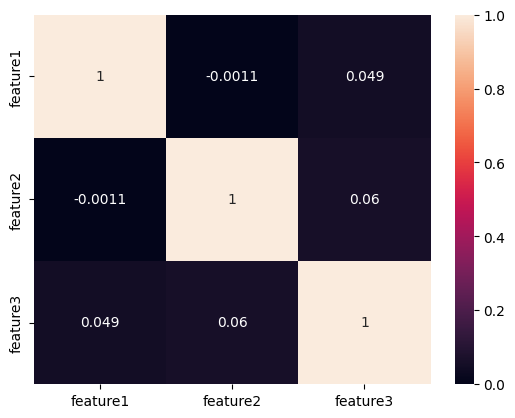

In [5]:
# To Check we Calculate variance inflation factor -> (VIF)i = 1 / 1 - (R2-score)i
# VIF = 1  -> Means No Corelation
# 1 < VIF < 5  -> Moderate Co-Relation
# VIF > 5 -> High Correlation -> MultiCollinearity (Remove that column to solve MultiCollinearity Problem) 

vif = []

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

# Print VIF    
print(pd.DataFrame({'vif': vif}, index=df.columns[0:3]).T)
# High Means that data measure is done by other column so remove that column

# Another Technique (Easy to apply without Training)
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

# Observation -> 
# Heat Map will Give Idea How Correlate are the columns to each other. 
# Check VIF for actual Visualization

3. Normality of Residual (Error)

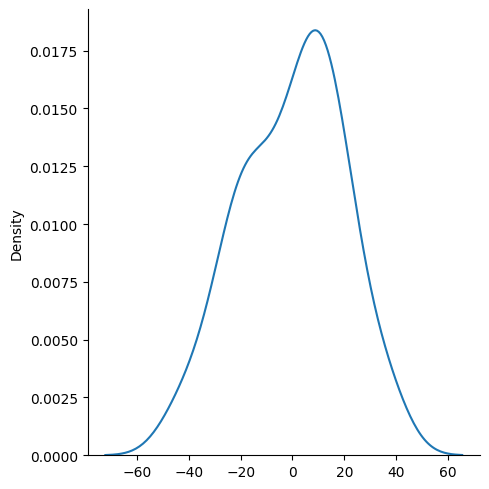

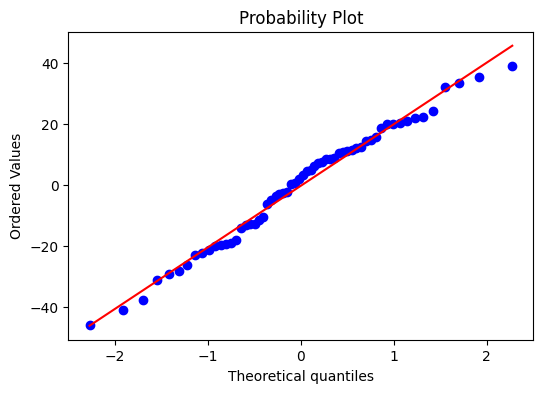

In [ ]:
# residual = y_test - y_pred
# Plot PDF
sns.displot(residual,kind='kde')

# Plot QQ Plot
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

# observation ->
# Data (Error -> Residual) should be Normally Distributed
# Error is Normally Distributed -> Okay

4. Homoscedasticity

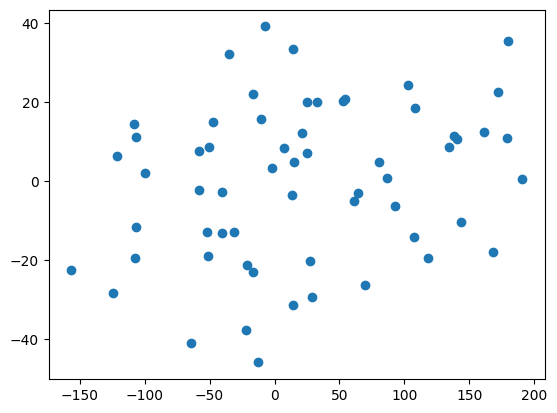

In [ ]:
# residual = y_test - y_pred

# Plot Scatter Plot

plt.scatter(y_pred,residual)

5. Autocorrelation of Residuals

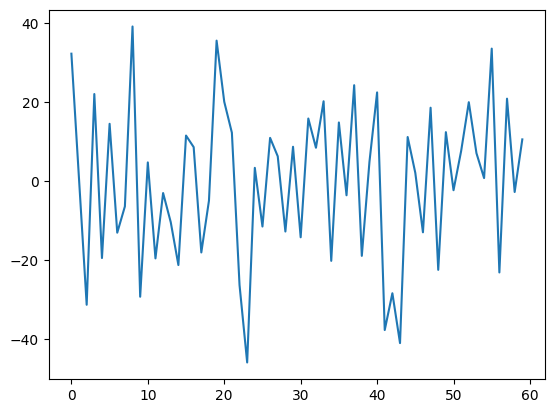

In [ ]:
# Plot Residual  (x -> count, y -> Error)

plt.plot(residual)